### Solución de proyecto de Regresión Lineal: Costos de seguros de vida 

1. Cargar los datos


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')

2. Analisis descriptivo - EDA 

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(1338, 7)

In [5]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(1)

In [7]:
columnas_duplicadas = data[data.duplicated()]
columnas_duplicadas

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
data = data.drop_duplicates().reset_index(drop = True)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [11]:
data_numerica = data.select_dtypes(include ='number')
corr_matrix = data_numerica.corr()

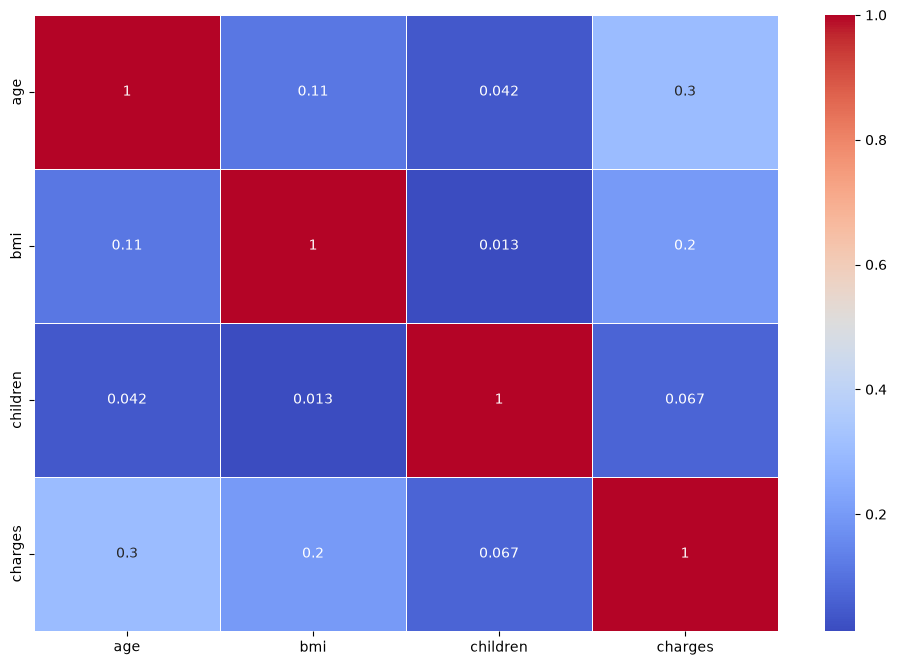

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap='coolwarm',
    linewidths =0.5,
    cbar=True,
)

plt.show()

3. Construcción de modelo Regresión Lineal

- Procesamiento de datos (Escalamiento de datos)

In [13]:
from sklearn.preprocessing import MinMaxScaler

data['sex_n'] = pd.factorize (data['sex'])[0]
data['smoker_n'] = pd.factorize (data['smoker'])[0]
data['region_n'] = pd.factorize (data['region'])[0]

num_variables = ['age', 'bmi', 'children', 'sex_n', 'smoker_n', 'region_n']

scaler = MinMaxScaler()
scal_features = scaler.fit_transform(data[num_variables])

data_scal = pd.DataFrame (scal_features, index= data.index, columns = num_variables)

data_scal['charges'] = data['charges']

data_scal.head()

,age,bmi,children,sex_n,smoker_n,region_n,charges
0,0.021739,0.321227,0.0,0.0,0.0,0.000000,16884.92400
1,0.000000,0.479150,0.2,1.0,1.0,0.333333,1725.55230
2,0.217391,0.458434,0.6,1.0,1.0,0.333333,4449.46200
3,0.326087,0.181464,0.0,1.0,1.0,0.666667,21984.47061
4,0.304348,0.347592,0.0,1.0,1.0,0.666667,3866.85520


In [14]:
corr_matrix = data_scal.corr()
corr_matrix

,age,bmi,children,sex_n,smoker_n,region_n,charges
age,1.000000,0.109344,0.041536,-0.019814,0.025587,-0.001626,0.298308
bmi,0.109344,1.000000,0.012755,0.046397,-0.003746,-0.157574,0.198401
children,0.041536,0.012755,1.000000,0.017848,-0.007331,-0.016258,0.067389
sex_n,-0.019814,0.046397,0.017848,1.000000,-0.076596,-0.004936,0.058044
smoker_n,0.025587,-0.003746,-0.007331,-0.076596,1.000000,-0.002358,-0.787234
region_n,-0.001626,-0.157574,-0.016258,-0.004936,-0.002358,1.000000,0.006547
charges,0.298308,0.198401,0.067389,0.058044,-0.787234,0.006547,1.000000


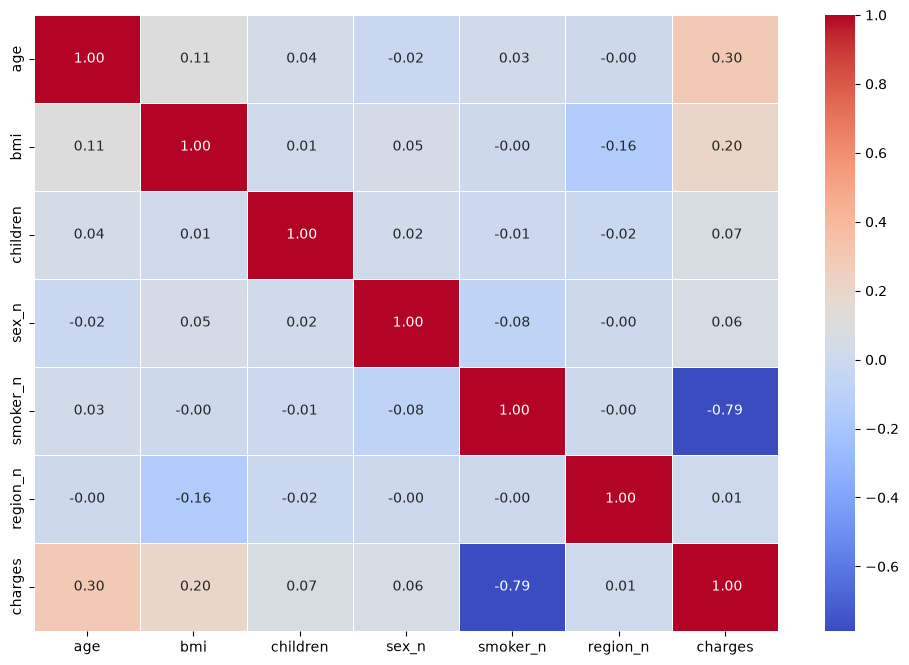

In [15]:
plt.figure ( figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt=' .2f',
    cmap='coolwarm',
    linewidths =0.5,
    cbar=True,
)

plt.show()

Se puede evidenciar que las variables que mas pueden tener relación con el charges son age y bmi y con las variables que menos tiene relación son smoker, es decir, ser fumadaro o no, no tiene nada que ver con el pago de seguro. En cambio, tener una mayoria de edad y un alto BMI si, esto se puede deducir, que a mayor indice corporal y edad es mas propenso a enfermedades.

- Selección de caracteristicas (Feature selection)

In [16]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

X = data_scal.drop('charges', axis = 1)
y = data_scal['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=42)

modelo_seleccion = SelectKBest (f_regression, k = 4)
modelo_seleccion.fit(X_train, y_train)

columnas_seleccion = X_train.columns[modelo_seleccion.get_support()]
X_train_sel = pd.DataFrame(modelo_seleccion.transform(X_train), columns = columnas_seleccion)
X_test_sel = pd.DataFrame (modelo_seleccion.transform(X_test), columns = columnas_seleccion)

X_train_sel.head()

,age,bmi,children,smoker_n
0,0.108696,0.230024,0.0,1.0
1,0.065217,0.263250,0.4,1.0
2,0.739130,0.580172,0.4,1.0
3,0.978261,0.686306,0.0,1.0
4,0.630435,0.286252,0.4,1.0


In [17]:
X_test_sel.head()

,age,bmi,children,smoker_n
0,0.673913,0.176352,0.0,1.0
1,0.239130,0.259349,0.8,1.0
2,0.717391,0.549502,0.6,1.0
3,0.282609,0.495830,0.6,0.0
4,0.282609,0.603444,0.4,1.0


In [18]:
X_train_sel['charges']= y_train.values
X_test_sel['charges']= y_test.values
X_train_sel.to_csv('../data/processed/clean_train.csv', index=False)
X_test_sel.to_csv('../data/processed/clean_test.csv', index=False)


- Desarrollo del modelo Regresión Lineal

In [19]:
train_data = pd.read_csv('../data/processed/clean_train.csv')
test_data = pd.read_csv('../data/processed/clean_test.csv')

train_data.head()

,age,bmi,children,smoker_n,charges
0,0.108696,0.230024,0.0,1.0,2396.09590
1,0.065217,0.263250,0.4,1.0,3279.86855
2,0.739130,0.580172,0.4,1.0,33471.97189
3,0.978261,0.686306,0.0,1.0,13405.39030
4,0.630435,0.286252,0.4,1.0,9715.84100


### Diagrama de dispersión

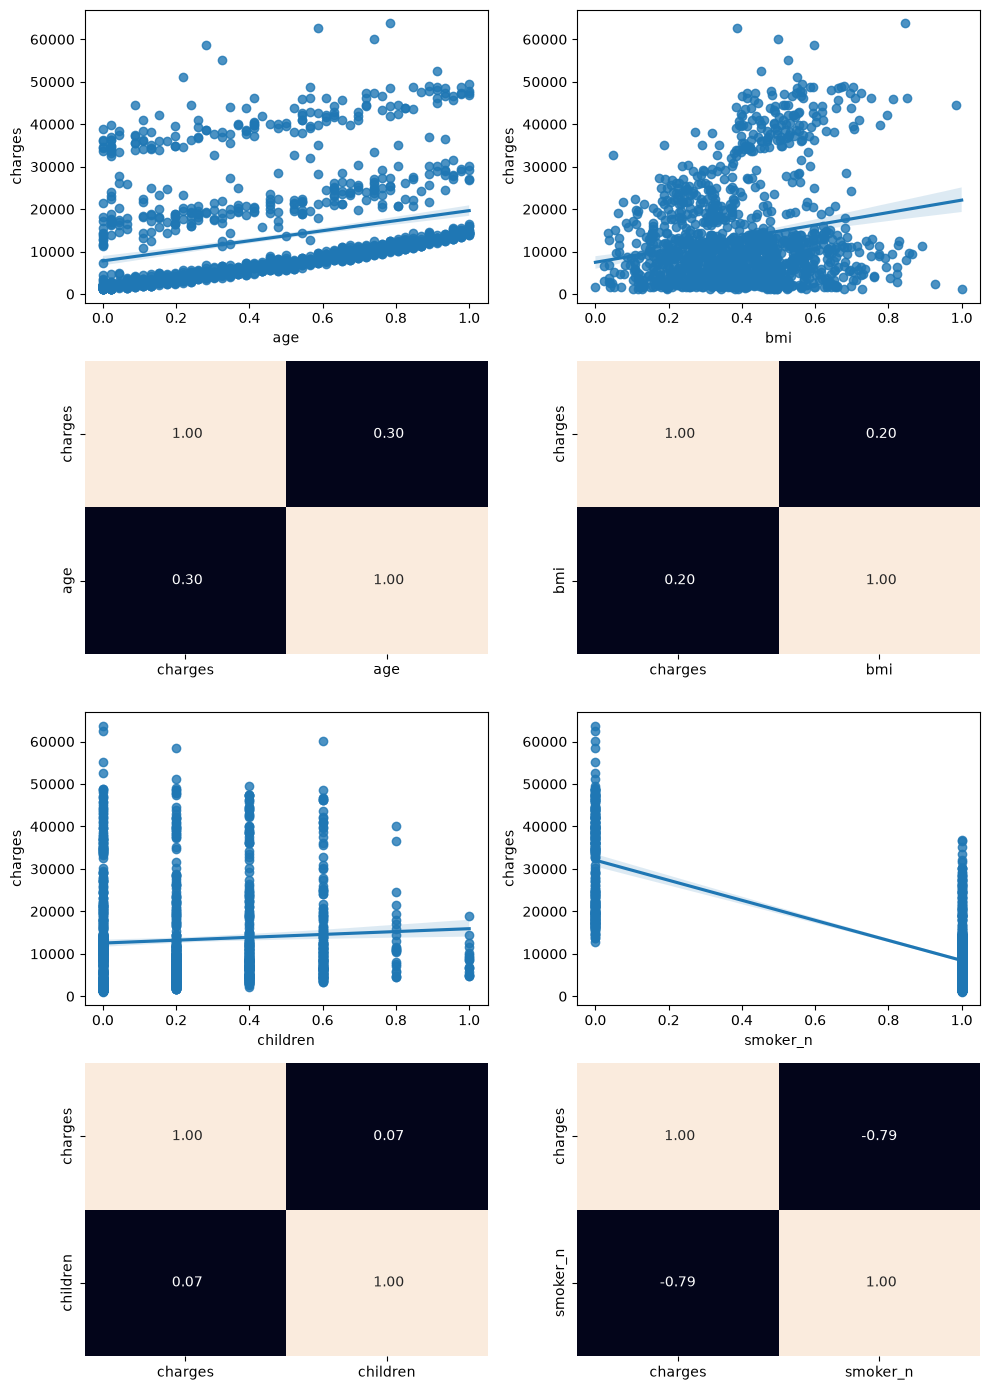

In [20]:
fig, axis = plt.subplots (4, 2, figsize = (10,14))
data = pd.concat([train_data, test_data])

sns.regplot(
    data = data,
    x= 'age',
    y= 'charges',
    ax = axis[0, 0], 
)

sns.heatmap(
    data[['charges','age']].corr(),
    annot = True,
    fmt =' .2f',
    ax=axis[1, 0],
    cbar=False
)

sns.regplot(
    data = data,
    x= 'bmi',
    y= 'charges',
    ax = axis[0, 1], 
)

sns.heatmap(
    data[['charges','bmi']].corr(),
    annot = True,
    fmt =' .2f',
    ax=axis[1, 1],
    cbar=False
)

sns.regplot(
    data = data,
    x= 'children',
    y= 'charges',
    ax = axis[2, 0], 
)

sns.heatmap(
    data[['charges','children']].corr(),
    annot = True,
    fmt =' .2f',
    ax=axis[3, 0],
    cbar=False
)

sns.regplot(
    data = data,
    x= 'smoker_n',
    y= 'charges',
    ax = axis[2, 1], 
)

sns.heatmap(
    data[['charges','smoker_n']].corr(),
    annot = True,
    fmt =' .2f',
    ax=axis[3,1],
    cbar=False
)

plt.tight_layout()
plt.show()

A partir de los graficos se concluye:
- Existe una relacion lineal entre la variable predictora (age) con la variable objetivo.
- La varible predictora (IBM) esta cerca de un comportamiento lineal pero tiene varios datos que generan dispersion 
- La varible predictora smoker tiene un comportamiento completamente opuesto a la variable objetivo, se puede evidenciar que la variable objetivo tiene un comportamiendo descendente.
- La variable predictora children tampoco tiene relacion lineal con la variable objetivo, pero se evidencia que a menor edad tiene un mayor costo 

In [21]:
X_train = train_data.drop(['charges'], axis =1)
y_train = train_data['charges']
X_test = test_data.drop(['charges'], axis=1)
y_test = test_data['charges']

In [22]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 11462.8 , 11346.79, 2689.86,-23042.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['age','bmi','children','smoker_n']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.114e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [23]:
print(f'Intercepto (a):{modelo.intercept_}')
print(f'Coeficientes (b1,b2): {modelo.coef_}')

Intercepto (a):21143.269121973935
Coeficientes (b1,b2): [ 11462.79943201  11346.78939471   2689.8609795  -23042.50723793]


In [24]:
y_pred = modelo.predict(X_test)
y_pred

array([ 7826.71976716,  5936.53265111, 14173.07782788, 31622.75075546,
        9263.34093635, 13480.14887712, 29787.25790395,  1643.45719872,
       10876.17888434, 11325.66257258, 10382.00922092, 33095.82145191,
       30563.99442887, 17375.68543919, 10170.05222026,  9793.97788271,
        4338.87322262, 32040.02942064,  3533.00631632,  5540.63300408,
        3800.90102672, 29849.73579925, 15058.38135413, 30681.25821127,
       30855.22159196,  5318.35517484, 35651.38184556, 36750.00646392,
       10887.72705446, 13731.47292098,  5951.31281261, 13057.0503156 ,
         885.50217102, 12378.3628904 , 39714.81547966, 12430.12415904,
        4898.39413804,  3922.99091642, 31372.98531615,  9306.77316642,
        6376.62829275, 29696.01315781, 35095.36875728, 11850.11609205,
        7372.07939253,  3596.50605624,  5524.8651415 ,  9123.94398722,
        4175.68935164,  9410.0034801 ,  6870.37575452, 11482.89235724,
       30753.06314612,  3901.63926993, 11213.80257282, 10152.26872403,
      

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

print(f'MSE:{mean_squared_error(y_test, y_pred)}')
print(f'R2 Score:{r2_score(y_test, y_pred)}')

MSE:35914551.48043366
R2 Score:0.8045531086669286


Se obtiene un R2 = 0,80, indica que tiene una regresión lineal positiva. 